## Script to read in, modify and plot aerosol emissions data for a CAM run
### - Read in data
### - Select region on globe modify the values of the data
### - Write to separate file.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import cartopy.crs as ccrs
from cartopy.feature import LAND


In [2]:
## Biomass burning files.

var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_bc_a4_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_DMS_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_pom_a4_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_SO2_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_so4_a1_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_SOAGx1.5_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'num_so4_a1_bb' ; emis_file = 'emissions-cmip6_num_so4_a1_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'num_bc_a4_bb' ; emis_file = 'emissions-cmip6_num_bc_a4_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'num_pom_a4_bb' ; emis_file = 'emissions-cmip6_num_pom_a4_bb_surface_2000climo_0.9x1.25_c20170509'



#var_name = 'emiss_anthro' ; emis_file =  'emissions-cmip6_bc_a4_anthro_surface_2000climo_0.9x1.25_c20170608'

#scale_factor = 0.0 ; fscale_factor = 'x0.0'
#scale_factor = 0.5 ; fscale_factor = 'x0.5'
#scale_factor = 2.0 ; fscale_factor = 'x2.0'
scale_factor = 10.0 ; fscale_factor = 'x10.0'

#region = 'amazon'
#region = 'na-boreal'
#region  = 'global'


emis_type = 'CMIP6_emissions_2000climo'
#emis_type = 'CMIP6_emissions_1750_2015'


emis_dir_out = '/glade/work/rneale/aero_howard/datasets/'
emis_dir_in = '/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/'
dir_png = '/glade/u/home/rneale/python/python-figs/'

In [3]:
emis_dir = emis_dir_in+emis_type+'/'


ds_in = xr.open_dataset(emis_dir+emis_file+'.nc')
da_in = ds_in[var_name]

In [4]:

# Masking domains
if region == 'amazon' : mmin_lon = 290. ;   mmax_lon = 315. ;   mmin_lat = -20.   ; mmax_lat = -5. ; pmin_lon = 270 ;   pmax_lon = 320. ;   pmin_lat = -30.  ; pmax_lat = 15.
if region == 'na-boreal' :   mmin_lon = 190. ;   mmax_lon = 310. ;   mmin_lat = 50.   ; mmax_lat = 70. ; pmin_lon = 181. ;   pmax_lon = 320. ;   pmin_lat = 40.  ; pmax_lat = 80.




# Sub-domain plot

#mask_lon = (da_in.lon >= pmin_lon) & (da_in.lon <= pmax_lon)
#mask_lat = (da_in.lat >= pmin_lat) & (da_in.lat <= pmax_lat)

#da_in = da_in.where(mask_lon & mask_lat, drop=True)

# Sub-domain plot mask

mask_lon = (da_in.lon >= mmin_lon) & (da_in.lon <= mmax_lon)
mask_lat = (da_in.lat >= mmin_lat) & (da_in.lat <= mmax_lat)

da_mod = da_in.copy()
#da_mod = da_mod.where(mask_lon & mask_lat, 1000) 


#da_mod.loc[{"lat": mask_lat, "lon": mask_lon}] = 10e16
da_mod.loc[{"lat": mask_lat, "lon": mask_lon}] = scale_factor*da_mod.loc[{"lat": mask_lat, "lon": mask_lon}]


#da_mod = vscale*da_mod
#ds_in[var_name].data = scale_factor*da_mod.data

ds_in[var_name] = da_mod





120.0 20.0 [190.0, 50.0]
na-boreal_emissions-cmip6_bc_a4_bb_surface_2000climo_0.9x1.25_c20170322.png


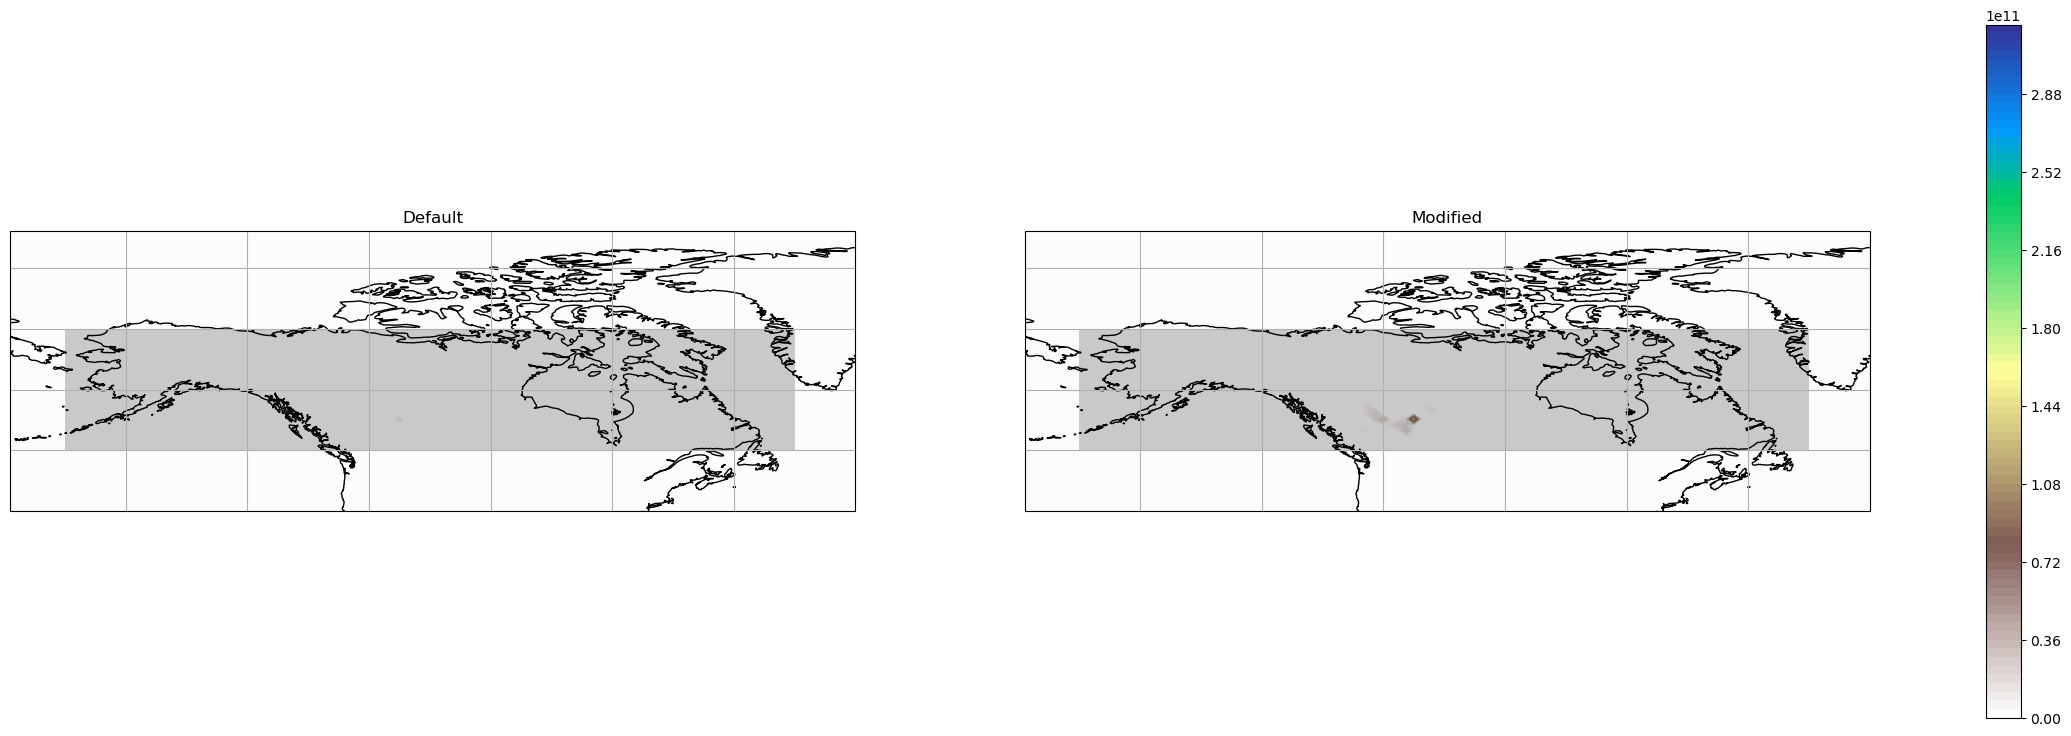

In [8]:
fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(30,15))

cmap = 'ocean_r'
cmap = 'terrain_r'

imonth = 0

cs1 = axs[0].contourf(da_in.lon,da_in.lat,da_in[imonth,:,:],levels=100,cmap=cmap)
cs2 = axs[1].contourf(da_mod.lon,da_mod.lat,da_mod[imonth,:,:],levels=100,cmap=cmap)

axs[0].set_global() if region == 'global' else  axs[0].set_extent([pmin_lon, pmax_lon, pmin_lat, pmax_lat])
axs[1].set_global() if region == 'global' else  axs[1].set_extent([pmin_lon, pmax_lon, pmin_lat, pmax_lat])



# Calculate box dims
bxy = [mmin_lon,mmin_lat]
bx = (mmax_lon-mmin_lon)
by = (mmax_lat-mmin_lat)

print(bx,by,bxy)

axs[0].add_patch(mpatches.Rectangle(xy=bxy, width=bx, height=by,
                                    facecolor='k',
                                    alpha=0.2,
                                    transform=ccrs.PlateCarree())
                 )

axs[1].add_patch(mpatches.Rectangle(xy=bxy, width=bx, height=by,
                                    facecolor='k',
                                    alpha=0.2,
                                    transform=ccrs.PlateCarree())
                 )

axs[0].gridlines()
axs[1].gridlines()
axs[0].add_feature(LAND,color='k')
axs[1].add_feature(LAND,color='k')

axs[0].set_title('Default')
axs[1].set_title('Modified')
axs[0].coastlines()
axs[1].coastlines()


cbar = fig.colorbar(cs1, ax=axs, location='right', shrink=0.6, pad=0.05)

print(region+'_'+emis_file+'.png')

plt.savefig(dir_png+region+'_'+emis_file+'.png', dpi=120, bbox_inches='tight') 
plt.show()

In [9]:
print(ds_in)


## OUTPUT NETCDF ##

print(emis_file+'_'+region+fscale_factor+'.nc')
ds_in.to_netcdf(path=emis_dir_out+emis_file+'_'+region+"_"+fscale_factor+'.nc')

<xarray.Dataset> Size: 3MB
Dimensions:   (lon: 288, lat: 192, time: 12)
Coordinates:
  * lon       (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lat       (lat) float32 768B -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * time      (time) datetime64[ns] 96B 2000-01-16T08:48:44.999999488 ... 200...
Data variables:
    date      (time) int32 48B ...
    emiss_bb  (time, lat, lon) float32 3MB ...
Attributes: (12/13)
    data_title:                Biomass burning emissions of bc_a4 for CMIP6
    molecular_weight:          12.0
    data_creator:              Jean-Francois Lamarque (lamar@ucar.edu) and Lo...
    data_summary:              Emissions from the Community Emission Data Sys...
    cesm_contact:              Louisa Emmons or Simone Tilmes
    creation_date:             20170322
    ...                        ...
    history:                   Thu Dec 21 11:30:20 2017: ncatted -a average,g...
    data_script:               /glade/u/home/emmons/CMIP6/emissio